# Instagram Sentiment-Weighted Engagement Regression Pipeline

This notebook demonstrates how to train regression models to predict the numeric value of `sentiment_weighted_engagement` for Instagram posts, using classic features and BERT embeddings. The pipeline includes data loading, feature selection, model training, and evaluation with logging.

In [26]:
# Install required packages (uncomment if running on Colab)
!pip install pandas numpy scikit-learn xgboost lightgbm joblib

In [27]:
# Imports
import os
import json
import pandas as pd
import numpy as np
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')

## 1. Upload Data Files
Upload your `engineered_data_filtered_with_bert.csv` and `preprocessed_data.csv` files to the Colab environment.

In [28]:
# If running in Colab, use this cell to upload files
#from google.colab import files
#uploaded = files.upload()

## 2. Load and Merge Data

In [29]:
# Paths to data files (update if needed)
engineered_path = 'engineered_data_filtered_with_bert.csv'
preprocessed_path = 'preprocessed_data.csv'

# Load data
logging.info('Loading engineered features...')
df_eng = pd.read_csv(engineered_path)
logging.info('Loading preprocessed features...')
df_pre = pd.read_csv(preprocessed_path)

# Merge on post_id
if 'post_id' in df_eng.columns and 'post_id' in df_pre.columns:
    df = pd.merge(df_eng, df_pre, on='post_id', suffixes=('', '_pre'))
else:
    df = df_eng.copy()
logging.info(f'Merged data shape: {df.shape}')

## 3. Feature Selection
Exclude IDs, timestamps, and target columns. Use only numeric features for regression.

In [30]:
# Exclude columns that are IDs, timestamps, target, and sentiment-related features
exclude_cols = {
    "post_id", "sentiment_weighted_engagement", "owner_id", "timestamp", "likes_pre", "comments_count",
    "location_id", "user_id_encoded", "engagement_binary", "engagement_probability",
    "sentiment_positive", "sentiment_negative", "sentiment_neutral", "avg_comment_sentiment"
}

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_columns = [col for col in numeric_cols if col not in exclude_cols]
X = df[feature_columns].fillna(0)
y = df["sentiment_weighted_engagement"].fillna(0)

logging.info(f'Feature columns used for training: {feature_columns}')
logging.info(f'Number of features: {len(feature_columns)}')

# Show top 10 feature correlations with target
corr = df[feature_columns + ["sentiment_weighted_engagement"]].corr()["sentiment_weighted_engagement"].sort_values(ascending=False)
print("Top 10 feature correlations with target:")
print(corr.head(11))

# Show sample data
print("Sample features (X):\n", X.head())
print("Sample target (y):\n", y.head())

Top 10 feature correlations with target:
sentiment_weighted_engagement    1.000000
num_comments                     0.757863
caption_bert_emb_2               0.276984
likes                            0.240449
caption_bert_emb_199             0.221729
caption_bert_emb_46              0.204587
comment_likes_sum                0.201952
caption_bert_emb_83              0.200928
hashtags_bert_emb_120            0.190130
caption_bert_emb_3               0.187536
caption_bert_emb_129             0.186081
Name: sentiment_weighted_engagement, dtype: float64
Sample features (X):
    likes  comment_likes_sum  num_comments  caption_bert_emb_0  \
0     80                  0            18           -0.118838   
1     80                  0            18           -0.118838   
2     80                  0            18           -0.118838   
3     80                  0            18           -0.118838   
4     80                  0            18           -0.118838   

   caption_bert_emb_1  caption_b

## 4. Train/Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
logging.info(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

## 5. Model Training and Evaluation
Train Random Forest, XGBoost, and LightGBM regressors. Evaluate with RMSE, MAE, and R².

In [32]:
results = {}

# Random Forest
print('Training Random Forest Regressor...')
logging.info('Training Random Forest Regressor...')
rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print('Random Forest training complete.')
y_pred_rf = rf.predict(X_test)
results['Random Forest'] = {
    'rmse': mean_squared_error(y_test, y_pred_rf) ** 0.5,
    'mae': mean_absolute_error(y_test, y_pred_rf),
    'r2': r2_score(y_test, y_pred_rf)
}
print(f"Random Forest Results: {results['Random Forest']}")

# XGBoost
print('Training XGBoost Regressor...')
logging.info('Training XGBoost Regressor...')
xgb = XGBRegressor(n_estimators=200, max_depth=7, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
print('XGBoost training complete.')
y_pred_xgb = xgb.predict(X_test)
results['XGBoost'] = {
    'rmse': mean_squared_error(y_test, y_pred_xgb) ** 0.5,
    'mae': mean_absolute_error(y_test, y_pred_xgb),
    'r2': r2_score(y_test, y_pred_xgb)
}
print(f"XGBoost Results: {results['XGBoost']}")

# LightGBM
print('Training LightGBM Regressor...')
logging.info('Training LightGBM Regressor...')
lgb = LGBMRegressor(n_estimators=200, max_depth=7, learning_rate=0.05, num_leaves=31, random_state=42)
lgb.fit(X_train, y_train)
print('LightGBM training complete.')
y_pred_lgb = lgb.predict(X_test)
results['LightGBM'] = {
    'rmse': mean_squared_error(y_test, y_pred_lgb) ** 0.5,
    'mae': mean_absolute_error(y_test, y_pred_lgb),
    'r2': r2_score(y_test, y_pred_lgb)
}
print(f"LightGBM Results: {results['LightGBM']}")

print('Training complete. Regression Results:')
logging.info('Training complete. Regression Results:')
for model_name, metrics in results.items():
    print(f"{model_name}: {metrics}")

Training Random Forest Regressor...
Random Forest training complete.
Random Forest Results: {'rmse': 0.8336796015339316, 'mae': 0.42650044406600685, 'r2': 0.9872112266104098}
Training XGBoost Regressor...
XGBoost training complete.
XGBoost Results: {'rmse': 0.1608064629169024, 'mae': 0.10165790028665299, 'r2': 0.9995241856452746}
Training LightGBM Regressor...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.340585 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 196644
[LightGBM] [Info] Number of data points in the train set: 16776, number of used features: 779
[LightGBM] [Info] Start training from score 12.468436
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

## 6. Save Models and Feature Columns (Optional)
You can save trained models and feature columns for later use.

In [33]:
# Save models and feature columns (uncomment to use)
joblib.dump(rf, 'rf_model.pkl')
joblib.dump(xgb, 'xgb_model.pkl')
joblib.dump(lgb, 'lgb_model.pkl')
with open('feature_columns.json', 'w') as f:
    json.dump(feature_columns, f, indent=2)

In [34]:
# 7.1 Try different feature sets or hyperparameters (example: top N features by correlation)
top_n = 20
top_features = corr.index[1:top_n+1].tolist()  # skip the first (target itself)
X_top = df[top_features].fillna(0)
X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(X_top, y, test_size=0.2, random_state=42)

print(f"Training Random Forest with top {top_n} features...")
rf_top = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_top.fit(X_train_top, y_train_top)
y_pred_top = rf_top.predict(X_test_top)
print(f"Top {top_n} feature RF RMSE:", mean_squared_error(y_test_top, y_pred_top) ** 0.5)

Training Random Forest with top 20 features...
Top 20 feature RF RMSE: 0.2781369681503411


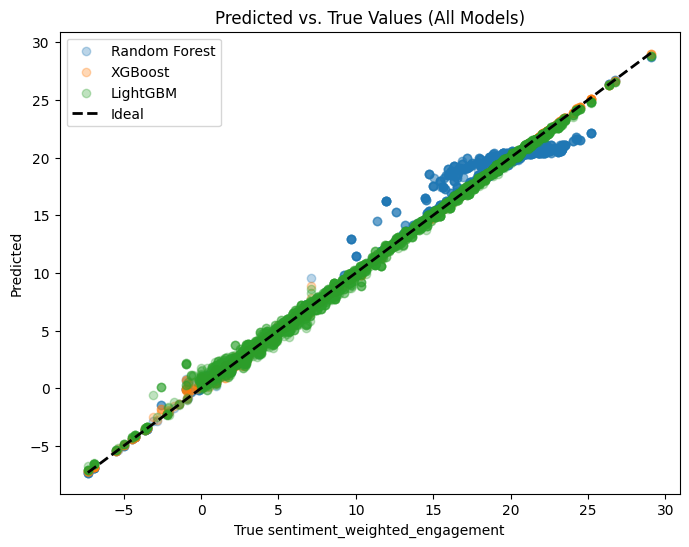

In [35]:
# 7.2 Visualize predictions vs. true values for all models
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='Random Forest')
plt.scatter(y_test, y_pred_xgb, alpha=0.3, label='XGBoost')
plt.scatter(y_test, y_pred_lgb, alpha=0.3, label='LightGBM')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal')
plt.xlabel('True sentiment_weighted_engagement')
plt.ylabel('Predicted')
plt.title('Predicted vs. True Values (All Models)')
plt.legend()
plt.show()

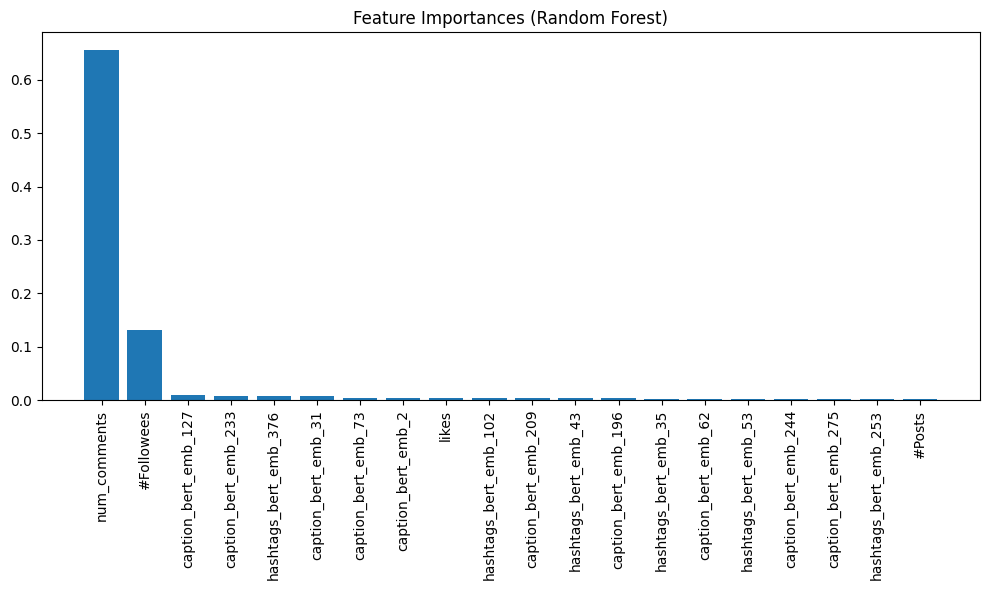

In [36]:
# 7.3 Feature importance for all models

# Random Forest
importances_rf = rf.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1]
plt.figure(figsize=(10, 6))
plt.title('Feature Importances (Random Forest)')
plt.bar(range(20), importances_rf[indices_rf][:20], align='center')
plt.xticks(range(20), [feature_columns[i] for i in indices_rf[:20]], rotation=90)
plt.tight_layout()
plt.show()


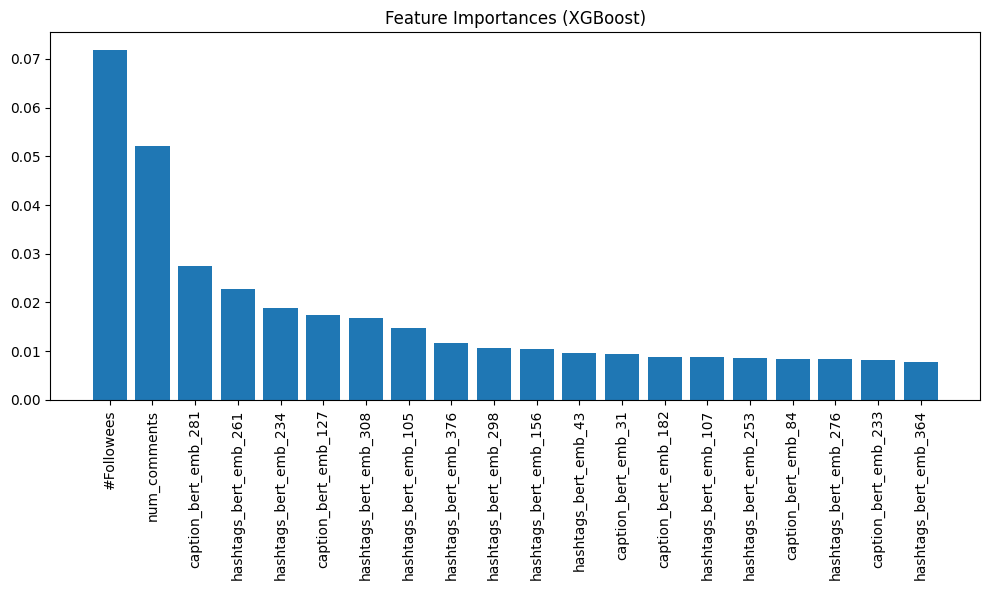

In [37]:

# XGBoost
importances_xgb = xgb.feature_importances_
indices_xgb = np.argsort(importances_xgb)[::-1]
plt.figure(figsize=(10, 6))
plt.title('Feature Importances (XGBoost)')
plt.bar(range(20), importances_xgb[indices_xgb][:20], align='center')
plt.xticks(range(20), [feature_columns[i] for i in indices_xgb[:20]], rotation=90)
plt.tight_layout()
plt.show()


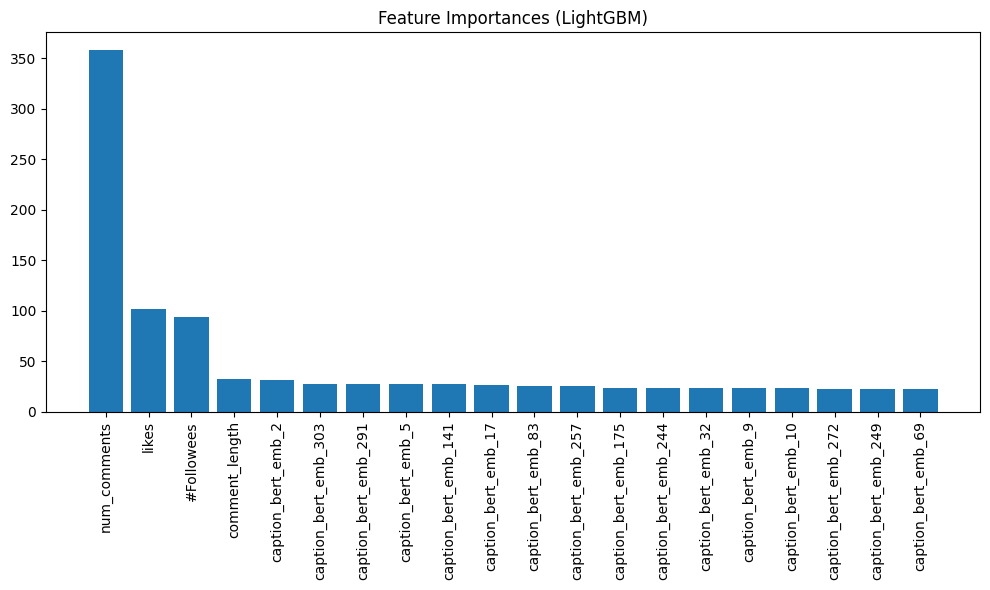

In [38]:

# LightGBM
importances_lgb = lgb.feature_importances_
indices_lgb = np.argsort(importances_lgb)[::-1]
plt.figure(figsize=(10, 6))
plt.title('Feature Importances (LightGBM)')
plt.bar(range(20), importances_lgb[indices_lgb][:20], align='center')
plt.xticks(range(20), [feature_columns[i] for i in indices_lgb[:20]], rotation=90)
plt.tight_layout()
plt.show()

Calculating SHAP values for Random Forest...


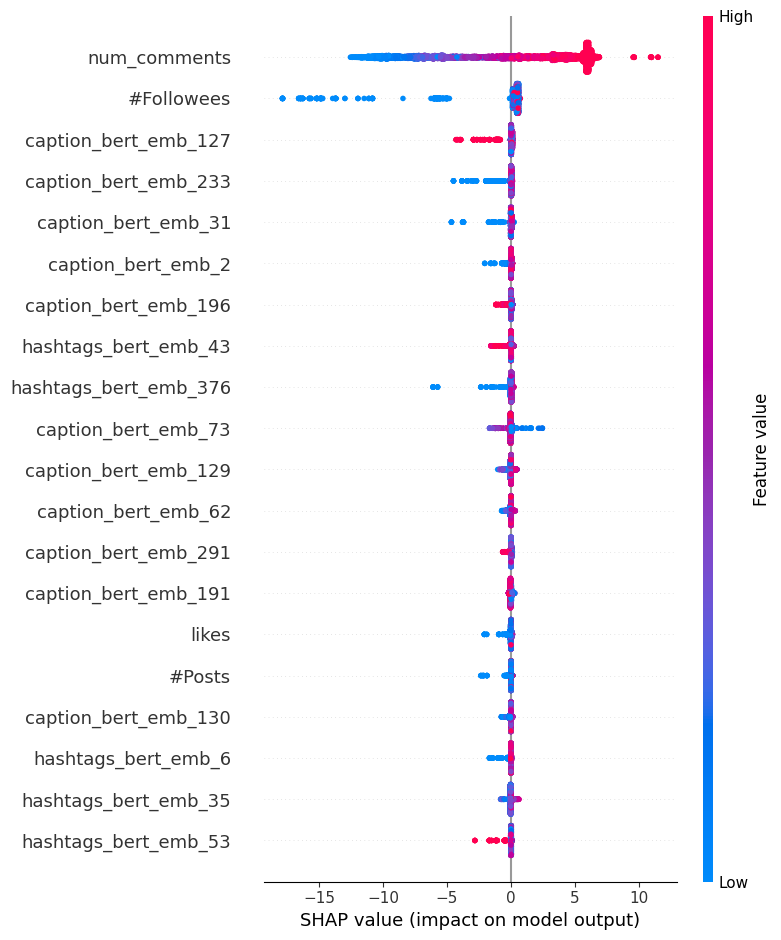

Calculating SHAP values for XGBoost...


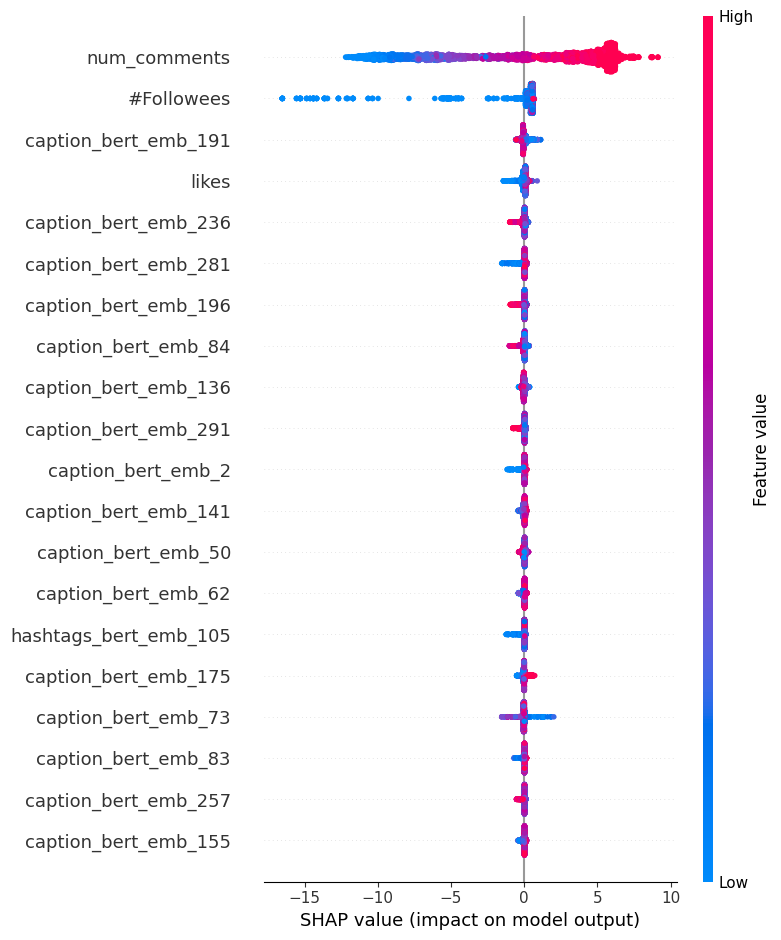

Calculating SHAP values for LightGBM...


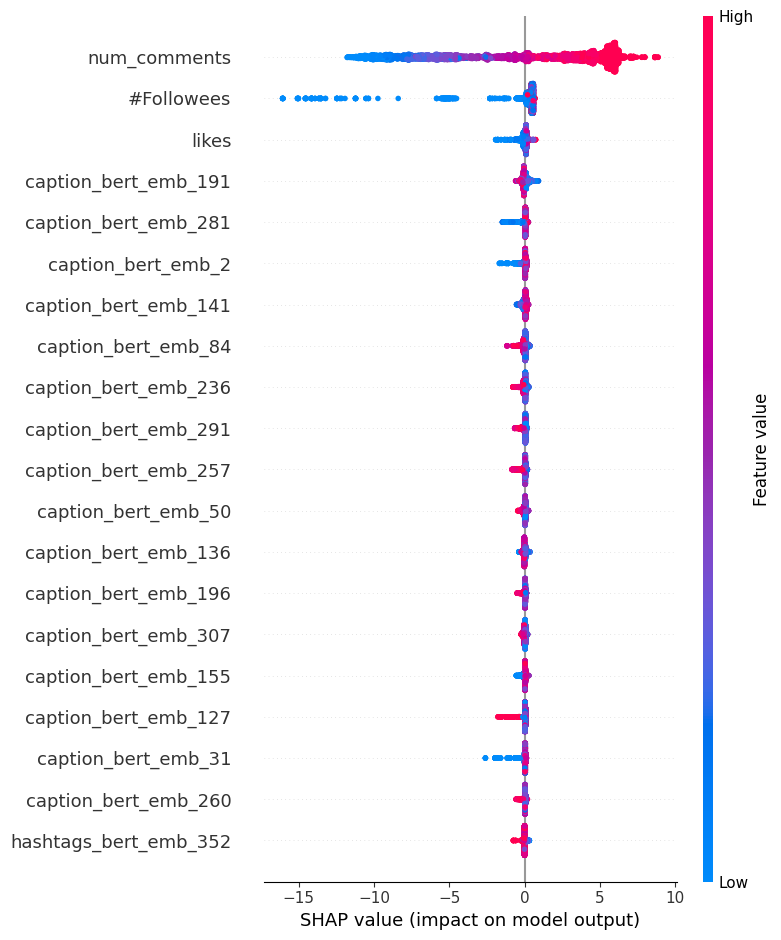

In [39]:

# 7.4 SHAP for model interpretation (Random Forest, XGBoost, LightGBM)
# !pip install shap
import shap

# Random Forest SHAP
print('Calculating SHAP values for Random Forest...')
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test)
shap.summary_plot(shap_values_rf, X_test, feature_names=feature_columns)

# XGBoost SHAP
print('Calculating SHAP values for XGBoost...')
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)
shap.summary_plot(shap_values_xgb, X_test, feature_names=feature_columns)

# LightGBM SHAP
print('Calculating SHAP values for LightGBM...')
explainer_lgb = shap.TreeExplainer(lgb)
shap_values_lgb = explainer_lgb.shap_values(X_test)
shap.summary_plot(shap_values_lgb, X_test, feature_names=feature_columns)